# Camera Binding Smoke Tests

Staged smoke tests for the EvoMachine camera API. Run the setup cell first, choose a binding in `SETTINGS`, then run the remaining cells in order. The virtual camera is the safe default; `MMC` and `PVCAM` connect to real camera software/hardware.

In [2]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)


def find_repo_root() -> Path:
    """Return the repository root containing the evomachine package."""
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "evomachine" / "peripherals" / "camera.py").is_file():
            return candidate
    raise RuntimeError("Could not find the EvoMachine repository root.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np

from evomachine.bindings.binding_types import BindingType
from evomachine.peripherals.camera import (
    CameraConfig,
    CameraFactory,
    CameraReadoutMode,
    ImageConfigType,
)
from evomachine.peripherals.peripheralcontrollers import (
    PeripheralControllerConfig,
    PeripheralControllerFactory,
)


@dataclass(frozen=True)
class CameraTestSettings:
    binding: BindingType = BindingType.PVCAM
    width: int = 3200
    height: int = 3200
    dtype: str = "uint16"
    exposure_ms: float = 30
    readout_mode: CameraReadoutMode | None = None
    random_seed: int = 1


# Change only this object when selecting a camera. For a Kinetix/PVCAM camera,
# ImageConfigTypeFactory.pv_cam() corresponds to 3200 x 3200 uint16 frames.
SETTINGS = CameraTestSettings(
    binding=BindingType.PVCAM,  # BindingType.VIRTUAL, BindingType.MMC, or BindingType.PVCAM
)
SETTINGS

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


CameraTestSettings(binding=<BindingType.PVCAM: 8>, width=3200, height=3200, dtype='uint16', exposure_ms=30, readout_mode=None, random_seed=1)

## Create and initialise the camera

Re-running this cell first releases camera objects created by an earlier run. Micro-Manager must already be running for `MMC`; the PVCAM SDK and a supported camera must be available for `PVCAM`.

In [3]:
import pycromanager

previous_camera = globals().get("camera")
if previous_camera is not None and previous_camera.is_initialised():
    previous_camera.finalise()
previous_controller = globals().get("camera_controller")
if previous_controller is not None and previous_controller.is_initialised():
    previous_controller.shutdown()

image_config = ImageConfigType(
    pxl_horiz=SETTINGS.width,
    pxl_vert=SETTINGS.height,
    pxl_dtype=np.dtype(SETTINGS.dtype),
)
camera_config = CameraConfig(
    binding=SETTINGS.binding,
    image=image_config,
    default_exposure_time=SETTINGS.exposure_ms,
    readout_mode=SETTINGS.readout_mode,
)

camera_controller = None
if SETTINGS.binding == BindingType.VIRTUAL:
    camera_controller = PeripheralControllerFactory.create(
        PeripheralControllerConfig(binding=BindingType.VIRTUAL)
    )
    camera = CameraFactory.create(
        config=camera_config,
        peripheral_controllers=camera_controller,
        random_seed=SETTINGS.random_seed,
    )
else:
    camera = CameraFactory.create(config=camera_config)

camera.initialise()
{
    "name": camera.name,
    "binding": camera.config.binding,
    "initialised": camera.is_initialised(),
    "alive": camera.is_alive(),
    "image_shape": camera.image.shape,
    "image_dtype": camera.image.pxl_dtype,
    "exposure_ms": camera.get_exposure(),
    "readout_mode": camera.readout_mode,
}

2026-07-02 09:54:43 - DEBUG - evomachine.peripherals.camera - Camera.initialise: initialising PVCAM Camera with force=False.
2026-07-02 09:54:44 - DEBUG - evomachine.peripherals.camera - Camera.set_exposure: setting PVCAM Camera exposure to 30 ms.
2026-07-02 09:54:44 - DEBUG - evomachine.peripherals.camera - Camera.initialise: PVCAM Camera initialised.


{'name': 'PVCAM Camera',
 'binding': <BindingType.PVCAM: 8>,
 'initialised': True,
 'alive': True,
 'image_shape': (3200, 3200),
 'image_dtype': dtype('uint16'),
 'exposure_ms': 30,
 'readout_mode': None}

## Capture and inspect one frame

2026-07-02 09:54:50 - DEBUG - evomachine.peripherals.camera - Camera.get_frame: capturing frame from PVCAM Camera with normalise=False.


shape=(3200, 3200), dtype=uint16, min=1.000, max=16.000, mean=1.435


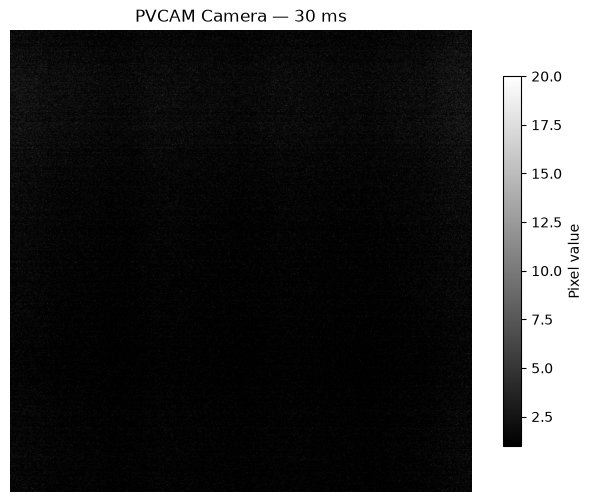

In [4]:
if "camera" not in globals() or not camera.is_initialised():
    raise RuntimeError("Run the camera creation cell first.")

frame = camera.get_frame()
print(
    f"shape={frame.shape}, dtype={frame.dtype}, "
    f"min={frame.min():.3f}, max={frame.max():.3f}, mean={frame.mean():.3f}"
)

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(frame, cmap="gray",vmax=20)
ax.set_title(f"{camera.name} — {camera.get_exposure()} ms")
ax.set_axis_off()
fig.colorbar(image, ax=ax, shrink=0.8, label="Pixel value")
plt.show()

## Change exposure and capture again

Keep the exposure conservative when using real hardware.

2026-07-01 15:01:28 - DEBUG - evomachine.peripherals.camera - Camera.set_exposure: setting PVCAM Camera exposure to 100 ms.
2026-07-01 15:01:28 - DEBUG - evomachine.peripherals.camera - Camera.get_frame: capturing frame from PVCAM Camera with normalise=False.


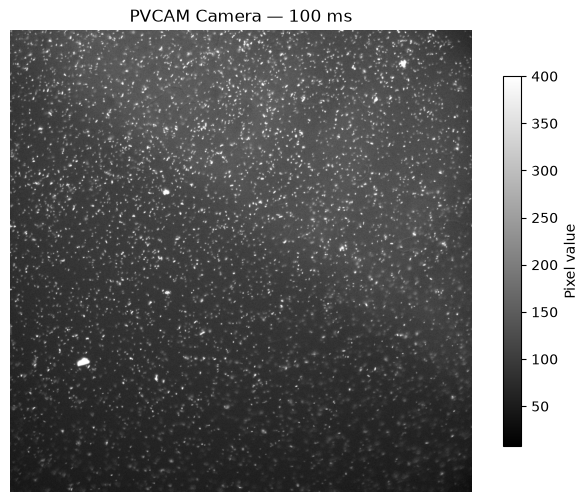

In [14]:
TEST_EXPOSURE_MS = 100

camera.set_exposure(TEST_EXPOSURE_MS)
exposure_frame = camera.get_frame()

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(exposure_frame, cmap="gray",vmax=400)
ax.set_title(f"{camera.name} — {camera.get_exposure()} ms")
ax.set_axis_off()
fig.colorbar(image, ax=ax, shrink=0.8, label="Pixel value")
plt.show()

## Check normalised capture

2026-07-01 15:02:10 - DEBUG - evomachine.peripherals.camera - Camera.get_frame: capturing frame from PVCAM Camera with normalise=True.


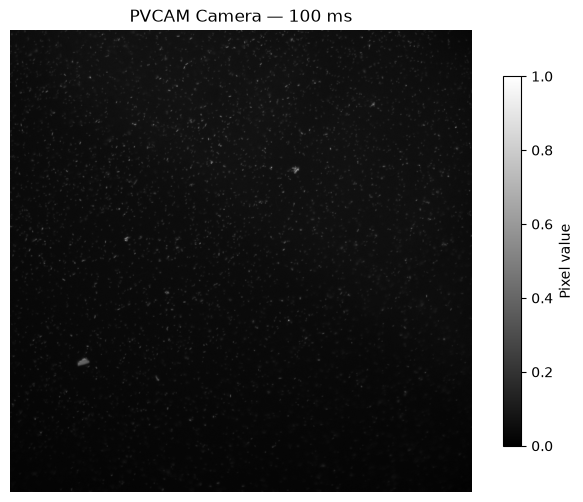

In [19]:
normalised_frame = camera.get_frame(normalise=True)
{
    "shape": normalised_frame.shape,
    "dtype": normalised_frame.dtype,
    "minimum": float(normalised_frame.min()),
    "maximum": float(normalised_frame.max()),
}


fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(normalised_frame, cmap="gray",vmax=1.0)
ax.set_title(f"{camera.name} — {camera.get_exposure()} ms")
ax.set_axis_off()
fig.colorbar(image, ax=ax, shrink=0.8, label="Pixel value")
plt.show()

## Cleanup

Run this cell before disconnecting hardware or switching bindings.

In [1]:
if "camera" in globals() and camera is not None:
    if camera.is_initialised():
        camera.stop()
        camera.finalise()

if "camera_controller" in globals() and camera_controller is not None:
    if camera_controller.is_initialised():
        camera_controller.shutdown()

{
    "camera_initialised": camera.is_initialised(),
    "controller_initialised": (
        camera_controller.is_initialised() if camera_controller is not None else None
    ),
}

NameError: name 'camera' is not defined